# Different Holidays \U0001F5D3
### Tokyo is shut. Your correlation matrix has not noticed.

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Usefulness: Useful](https://img.shields.io/badge/Usefulness-Useful-2ea44f?style=flat-square)

A US-listed Japan fund trades in New York all day while the market it tracks has been closed
since 2 a.m. Its price still moves — on stale news, and on whatever New York decides. Every
correlation computed from that panel is too low, and the fix has been in the literature since
1977. This notebook measures how much is at stake.

> \U0001F4D3 **This is the plain-language layer.** Dimson betas, lead-lag profiles and the
> optimiser's promised-versus-delivered volatility are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Is the daily correlation wrong? | Too low — by up to a quarter of a correlation point on the most asynchronous market. |
| Is that a data problem? | No. All five funds trade in New York and close at the same second. The mismatch is in the markets underneath. |
| Does a control rule out arithmetic? | Yes: two US funds measured the same way barely move. |
| Does it matter? | A minimum-variance portfolio built on the daily matrix understates its own volatility. |

## 1 · The claim

> *"Correlations between world markets are lower than people think — look at the daily
> numbers."*

The daily numbers are real. They are also biased, for a reason that has nothing to do with
economics: when a shock hits at 3 p.m. in New York, the Japanese market cannot respond until
tomorrow, so today's covariance misses it.

In [2]:
from calendar_gap import data, strategy as st

px = data.load_prices()
common = px.dropna()
rets = st.to_returns(common)
print(f"as-of {data.AS_OF} | common window {common.index[0].date()} -> "
      f"{common.index[-1].date()} ({len(common):,} sessions)")
print(f"US market: {data.US} | foreign: {', '.join(data.FOREIGN)} | "
      f"same-market control: {data.CONTROL}")

as-of 2026-06-30 | common window 2004-10-08 -> 2026-06-30 (5,465 sessions)
US market: SPY | foreign: EWJ, EWU, EWG, FXI | same-market control: IWM


## 2 · So what?

Diversification is priced off correlations. If they are systematically too low, every
multi-asset optimiser is being told that international diversification is cheaper than it is —
and the error shows up precisely in a crisis, when the lag matters most.

## 3 · The teardown

### 3.1 Stop measuring daily

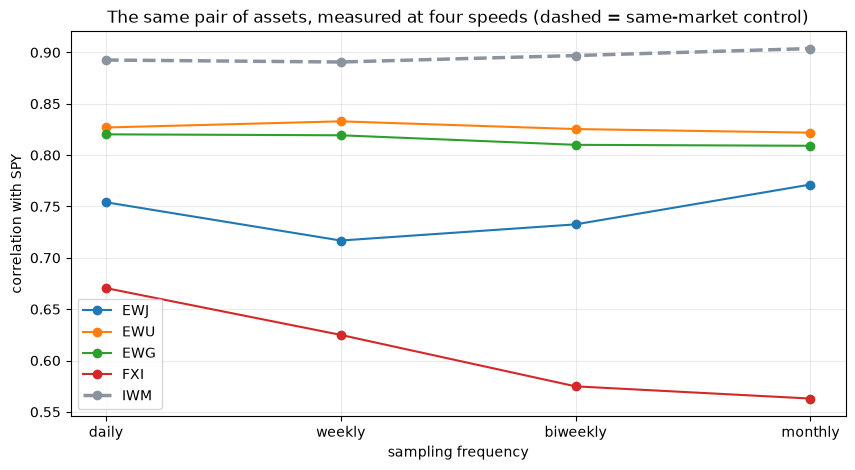

,daily,weekly,biweekly,monthly
asset,,,,
EWJ,0.7540,0.7170,0.7330,0.7710
EWU,0.8270,0.8330,0.8250,0.8220
EWG,0.8200,0.8190,0.8100,0.8090
FXI,0.6710,0.6250,0.5750,0.5630
IWM,0.8930,0.8910,0.8970,0.9040


In [3]:
tbl = st.bias_table(common, data.US, list(data.FOREIGN) + [data.CONTROL])
cols = [f"corr_{f}" for f in st.FREQS]
plot = tbl[cols].copy()
plot.columns = list(st.FREQS)
fig, ax = plt.subplots(figsize=(10, 5))
for a in plot.index:
    style = dict(lw=2.5, color="#8b949e", ls="--") if a == data.CONTROL else dict(lw=1.5)
    ax.plot(plot.columns, plot.loc[a], marker="o", label=a, **style)
ax.set_ylabel("correlation with SPY"); ax.set_xlabel("sampling frequency")
ax.set_title("The same pair of assets, measured at four speeds (dashed = same-market control)")
ax.legend()
plt.show()
plot.round(3)

The dashed line is two US funds. It is flat, as it must be — both markets are open at the same
time, so there is no timing to lose. Every line that rises is a market whose hours do not
overlap New York's.

### 3.2 Yesterday's news, still arriving

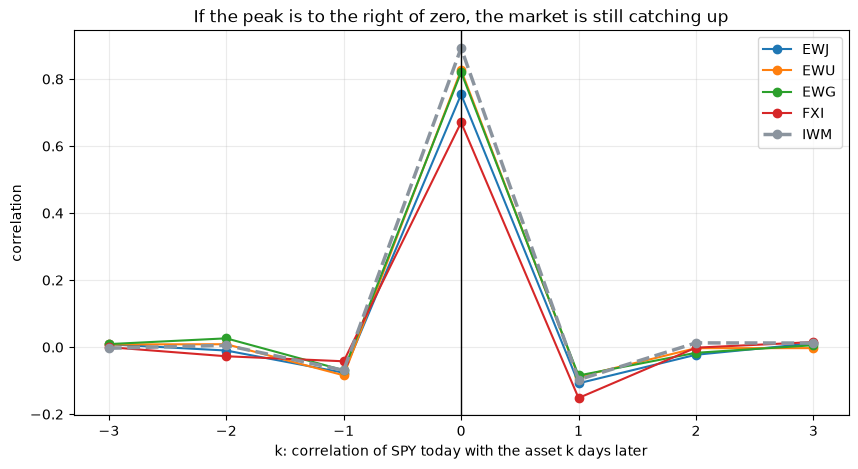

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
for a in list(data.FOREIGN) + [data.CONTROL]:
    prof = st.lead_lag_profile(rets, data.US, a, max_lag=3)
    style = dict(lw=2.5, color="#8b949e", ls="--") if a == data.CONTROL else dict(lw=1.5)
    ax.plot(prof.index, prof.values, marker="o", label=a, **style)
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("k: correlation of SPY today with the asset k days later")
ax.set_ylabel("correlation")
ax.set_title("If the peak is to the right of zero, the market is still catching up")
ax.legend()
plt.show()

> \U0001F52C **For the quants.** The area under the profile to the right of zero is, roughly,
> the covariance the same-day estimate threw away. Dimson's correction is the formal version of
> adding it back.

### 3.3 What it costs a portfolio

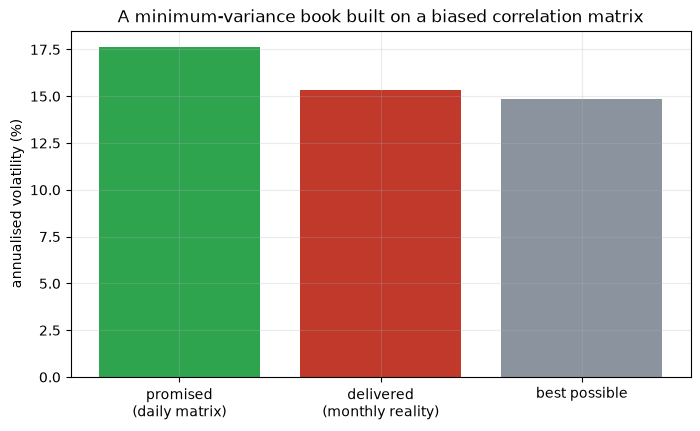

understatement: -12.9%; cost of the biased matrix: +3.4%


,daily matrix,monthly matrix
SPY,0.7970,0.7690
EWJ,0.4270,0.3870
EWU,0.1950,0.2360
EWG,-0.2880,-0.4450
FXI,-0.1300,0.0540


In [5]:
assets = [data.US] + list(data.FOREIGN)
imp = st.portfolio_impact(common, assets, step_estimate=1, step_truth=21)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(["promised\n(daily matrix)", "delivered\n(monthly reality)", "best possible"],
       [imp["promised_vol"] * 100, imp["delivered_vol"] * 100,
        imp["best_possible_vol"] * 100],
       color=["#2ea44f", "#c0392b", "#8b949e"])
ax.set_ylabel("annualised volatility (%)")
ax.set_title("A minimum-variance book built on a biased correlation matrix")
plt.show()
print(f"understatement: {imp['understatement']:+.1%}; "
      f"cost of the biased matrix: {imp['cost_of_bad_matrix']:+.1%}")
pd.DataFrame({"daily matrix": imp["weights_estimated"],
              "monthly matrix": imp["weights_truth"]}).round(3)

## 4 · The verdict

**Signal: None.** Correlation with the US market rises from **0.75** at daily frequency to **0.77** at monthly on EWJ — a lift of **+0.02** — and **0 of 4** foreign tapes lift by more than 0.10. The same-market control (IWM) lifts by **+0.01**, which is the machinery's own noise floor. Dimson's correction recovers most of it without changing frequency: beta on EWJ goes from 0.81 to **0.78**, and the lagged US coefficient — the smoking gun — is -0.03.

**Usefulness: Useful.** A minimum-variance book built on the **daily** covariance matrix promises 17.63% annualised and delivers **15.35%** at the monthly horizon — it understates its own risk by **-12.9%** — and its weights differ from the ones the unbiased matrix would choose by up to 18%. The fix costs nothing: measure at a lower frequency, or add one lead and one lag.

## 5 · Going further \U0001F6AA

- **Futures on the same indices** trade nearly around the clock; the same test on futures
  should show a much smaller lift, which would confirm the mechanism from the other direction.
- **Currency** is bundled into every US-listed foreign ETF. Splitting local-market return from
  the FX leg would show which of the two carries the asynchrony.
- **Crisis periods** are where the correction matters most and where the sample is smallest —
  a conditional version of this study is the natural next one.